In [ ]:
# analysis.py — tailored to your vary_B data layout
import sys
import os
import re
from tqdm import tqdm
import torch
import torch.optim as optim
import numpy as np

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 1

# --------- CLI ---------
# Usage:
#   python analysis.py B n_i seed
#   python analysis.py B n_i seed phi snr
# #if len(sys.argv) < 4:
#     raise ValueError("Usage: python analysis.py B n_i seed [phi snr]")

B_arg   = 121
n_i_arg = 6
seed    = 2

phi_cli = None
# if len(sys.argv) >= 6:
#     phi_cli = float(sys.argv[4])
#     snr_cli = float(sys.argv[5])

# --------- Resolve data path ---------
import os, re

# --------- Resolve data path ---------
base_dir = os.path.join('..', 'data', 'vary_B2', f'B_{B_arg}_n_{n_i_arg}')

def autodetect_phi(folder):
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    candidates = [
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d)) and d.startswith('phi_')
    ]
    if len(candidates) == 0:
        raise FileNotFoundError(f"No phi subfolders found in {folder}")
    if len(candidates) > 1:
        raise ValueError(
            f"Multiple phi folders found in {folder}: {candidates}. "
            f"Re-run with explicit phi."
        )
    d = candidates[0]  # e.g., 'phi_2.0'
    m = re.match(r'^phi_([^/]+)$', d)
    if not m:
        raise ValueError(f"Cannot parse phi from folder name: {d}")
    return float(m.group(1)), d

# If phi not passed on CLI, auto-detect it
if phi_cli is None:
    phi_resolved, phi_dir = autodetect_phi(base_dir)
else:
    phi_resolved = phi_cli
    phi_dir = f"phi_{phi_resolved}"

data_path = os.path.join(base_dir, phi_dir, f"data_seed_{seed}.pt")

# --------- Load data ---------
data = torch.load(data_path, map_location=device)

y  = data['y'].to(device).float()
x  = data['x'].to(device).float()
w  = data['w'].to(device).float()
e  = data['e'].to(device).float()
s  = data['s'].to(device).float()
region_assignments = data['region_assignments'].to(device).long()

x_jumbled_within_regions = data['x_jumbled_within_regions'].to(device).float()
s_jumbled_within_regions = data['s_jumbled_within_regions'].to(device).float()

perm_matrix_x = data['perm_matrix_x'].to(device).float()
perm_matrix_s = data['perm_matrix_s'].to(device).float()

sigmasq_true = float(data['sigmasq_true'])
phi_true     = float(data['phi_true'])
beta_true    = float(data['beta_true'])
nu_true      = float(data['nu_true'])
tausq_true   = float(data['tausq_true'])
snr_true     = float(data.get('snr', snr_resolved))

# Sanity: unique region count
unique_regions = torch.unique(region_assignments)
B_in_data = len(unique_regions)
if B_in_data != B_arg:
    print(f"[WARN] B in data ({B_in_data}) != B from CLI ({B_arg}). Using B_in_data for shapes.")
n_blocks = B_in_data
n_locations = n_i_arg  # expected design; will assert below

N = y.numel()
if N % n_blocks != 0:
    raise ValueError(f"N={N} not divisible by B={n_blocks}")
if n_locations != (N // n_blocks):
    print(f"[WARN] n_i from CLI ({n_i_arg}) != inferred ({N // n_blocks}). Using inferred.")
    n_locations = N // n_blocks

# --------- Training iters ---------
niter_GP = 3000
niter_GPAreal = 3000
niter_VI = 100

result = {}
torch.manual_seed(521)

# ===================== 1) Oracle GP (locations & links known) =====================
gp = GPModel().to(device)
opt = optim.AdamW(gp.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(niter_GP), desc="Train GPModel (oracle)"):
    opt.zero_grad()
    loss = gp(s, x, y)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gp.sigmasq.clamp_(min=1e-6)
    #     gp.phi.clamp_(min=1e-6)
    #     gp.tausq.clamp_(min=1e-6)

result['GPmodel'] = {
    'nu': float(gp.nu.item()),
    'phi': float(np.exp(gp.logphi.item())),
    'sigmasq': float(np.exp(gp.logsigmasq.item())),
    'tausq': float(np.exp(gp.logtausq.item())),
    'beta': gp.beta.detach().float().cpu().numpy(),
    'true_params': {
        'nu_true': nu_true, 'phi_true': phi_true, 'sigmasq_true': sigmasq_true,
        'tausq_true': tausq_true, 'beta_true': beta_true, 'snr_true': snr_true
    }
}

# ===================== 2) Areal GP (region-averaged) =====================
# Region-wise averages
ybar = torch.zeros(n_blocks, device=device)
xbar = torch.zeros(n_blocks, input_dim, device=device)
for i, region in enumerate(unique_regions):
    idx = torch.where(region_assignments == region)[0]
    ybar[i] = torch.mean(y[idx])
    xbar[i] = torch.mean(x_jumbled_within_regions[idx], dim=0)

gpa = GPArealModel().to(device)
opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)
for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel"):
    opt.zero_grad()
    loss = gpa(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gpa.sigmasq.clamp_(min=1e-6)
    #     gpa.phi.clamp_(min=1e-6)
    #     gpa.tausq.clamp_(min=1e-6)

result['GPArealModel'] = {
    'nu': float(gpa.nu.item()),
    'phi': float(np.exp(gpa.logphi.item())),
    'sigmasq': float(np.exp(gpa.logsigmasq.item())),
    'tausq': float(np.exp(gpa.logtausq.item())),
    'beta': gpa.beta.detach().float().cpu().numpy()
}

# ===================== 3) VI for Unlinked GP =====================
# Reshape to (B, n_i)
X = x_jumbled_within_regions.reshape(n_blocks, n_locations).contiguous()
Y = y.reshape(n_blocks, n_locations).contiguous()

locations = s_jumbled_within_regions  # (N, d)
Dist = torch.cdist(locations, locations, p=2)
Dist = (Dist + Dist.T) / 2

n_steps = 50
n_phi_samples = 100
n_piX_sample = 50
n_piS_sample = 50

prior_parameters = {
    "a1": 0.1, "b1": 0.1,
    "a2": 0.1, "b2": 0.1,
    "eta_X_sq": 0.1, "eta_S_sq": 0.1,
    "mu_beta": 0.0, "sigmasq_beta": 100.0,
    "phi_prior_lb": 1/torch.max(Dist),
    "phi_prior_ub":100/torch.max(Dist)
}

# results_VI = VIGP_Unlinked(
#         n_iter=niter_VI,
#         n_blocks=n_blocks,
#         n_locations=n_locations,
#         X=X, Y=Y,
#         Dist=Dist,
#         n_steps=n_steps,
#         n_phi_samples=n_phi_samples,
#         n_piX_sample=n_piX_sample,
#         tau_X=0.8, tau_S=0.8,
#         n_piS_sample=n_piS_sample,
#         seed=521,
#         fix_piX=False, fix_piS=False,
#         fix_mu_lambda_beta=False,
#         fix_sigmasq_lambda_beta=False,
#         fix_lambda_b1=False,
#         lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
#         fix_lambda_b2=False,
#         M_X_star_fixed=perm_matrix_x.T,
#         M_S_star_fixed=perm_matrix_s.T,
#         V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
#         V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
#         phi_init=0.5,
#         mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
#         fix_mean_Rphi_inv=False,
#         pi_X_true=perm_matrix_x.T,
#         pi_S_true=perm_matrix_s.T,
#         VX_ub=0.5, VS_ub=0.5,
#         lr_piS=0.01, lr_piX=0.01,
#         prior_parameters=prior_parameters,
#         anneal_every=10, elbo_W=5
#     )

for tau in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    results_VI = VIGP_Unlinked(
        n_iter=niter_VI,
        n_blocks=n_blocks,
        n_locations=n_locations,
        X=X, Y=Y,
        Dist=Dist,
        n_steps=n_steps,
        n_phi_samples=n_phi_samples,
        n_piX_sample=n_piX_sample,
        tau_X=tau, tau_S=tau,
        n_piS_sample=n_piS_sample,
        seed=521,
        fix_piX=False, fix_piS=False,
        fix_mu_lambda_beta=False,
        fix_sigmasq_lambda_beta=False,
        fix_lambda_b1=False,
        lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
        fix_lambda_b2=False,
        M_X_star_fixed=perm_matrix_x.T,
        M_S_star_fixed=perm_matrix_s.T,
        V_X_star_fixed=torch.eye(n_locations, n_locations, device=device),
        V_S_star_fixed=torch.eye(n_locations, n_locations, device=device),
        phi_init=0.1,
        mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
        fix_mean_Rphi_inv=False,
        pi_X_true=perm_matrix_x.T,
        pi_S_true=perm_matrix_s.T,
        VX_ub=0.5, VS_ub=0.5,
        lr_piS=0.01, lr_piX=0.01,
        prior_parameters=prior_parameters
    )
#     result[f'VIGP_unlinked_tau_{tau}'] = results_VI

# # --------- Save results ---------
# results_dir = os.path.join('..', 'data', 'results', 'vary_B',
#                            f'B_{B_arg}_n_{n_i_arg}', phi_snr_dir)
# os.makedirs(results_dir, exist_ok=True)
# result_path = os.path.join(results_dir, f'results_seed_{seed}.pt')
# torch.save(result, result_path)
# print(f"[OK] Saved results to {result_path}")

# taus = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]  # soft-start high -> low

# init_state = None
# all_results = {}

# for tau in taus:
#     results_VI = VIGP_Unlinked(
#         n_iter=niter_VI,
#         n_blocks=n_blocks,
#         n_locations=n_locations,
#         X=X, Y=Y,
#         Dist=Dist,
#         n_steps=n_steps,
#         n_phi_samples=n_phi_samples,
#         n_piX_sample=n_piX_sample,
#         tau_X=tau, tau_S=tau,
#         n_piS_sample=n_piS_sample,
#         seed=521,

#         fix_piX=False, fix_piS=False,
#         fix_mu_lambda_beta=False,
#         fix_sigmasq_lambda_beta=False,
#         fix_lambda_b1=False,
#         lambda_b1_fixed=((n_blocks * n_locations) * 0.5 + 0.1) * 5,
#         fix_lambda_b2=False,

#         # only use "truth" initialization on the FIRST run if you want:
#         M_X_star_fixed=perm_matrix_x.T if init_state is None else None,
#         M_S_star_fixed=perm_matrix_s.T if init_state is None else None,
#         V_X_star_fixed=torch.eye(n_locations, device=device),
#         V_S_star_fixed=torch.eye(n_locations, device=device),

#         phi_init=0.5,
#         mean_Rphi_inv_fixed=torch.linalg.inv(torch.exp(-4 * Dist)),
#         fix_mean_Rphi_inv=False,

#         pi_X_true=perm_matrix_x.T,
#         pi_S_true=perm_matrix_s.T,

#         VX_ub=0.5, VS_ub=0.5,
#         lr_piS=0.01, lr_piX=0.01,
#         prior_parameters=prior_parameters,

#         # NEW:
#         init_state=init_state,
#         warm_start=True,
#     )

#     all_results[tau] = results_VI

#     # feed forward warm-start state (choose what you want to carry)
#     init_state = {
#         "M_X_star": results_VI["M_X_star"],
#         "V_X_star": results_VI["V_X_star"],
#         "M_S_star": results_VI["M_S_star"],
#         "V_S_star": results_VI["V_S_star"],
#         "mu_lambda_beta": results_VI["mu_lambda_beta"],
#         "sigmasq_lambda_beta": results_VI["sigmasq_lambda_beta"],
#         "mu_W": results_VI.get("mu_W", None),
#         "Sigma_W": results_VI.get("Sigma_W", None),
#         "mean_Rphi_inv": results_VI["mean_Rphi_inv"],
#     }
#     # drop Nones (if you didn't return mu_W / Sigma_W yet)
#     init_state = {k: v for k, v in init_state.items() if v is not None}

#     print(f"[warm-start] completed tau={tau}, next run will start from this solution.")


  0%|          | 0/100 [00:00<?, ?it/s]

Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: -1.3007e-07
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: -1.3007e-07


  1%|          | 1/100 [00:23<38:10, 23.13s/it]

Iter 1/100 | mu_lambda_beta: 1.1312 | 
 sigmasq_lambda_beta: 0.0000 | 
 lambda_a1: 363.1000 | lambda_b1: 3922.0112 | lambda_a2: 363.1000 | lambda_b2: 22593.5918
‣  E[ϕ]: 0.4664 | ‣ E[Sigmasq*ϕ]: 5.0521 | ‣ ||mu_W||: 39.4549
Number of correct permutations recognized for piX: 6.0
Number of correct permutations recognized for piS: 6.0
Total ELBO: -2471.1250
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 4.7483e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 4.8363e-03


  2%|▏         | 2/100 [00:46<38:08, 23.36s/it]

...

Iter 11/100 | mu_lambda_beta: 7.9965 | 
 sigmasq_lambda_beta: 0.0032 | 
 lambda_a1: 363.1000 | lambda_b1: 2726.4307 | lambda_a2: 363.1000 | lambda_b2: 726.1933
‣  E[ϕ]: 0.1704 | ‣ E[Sigmasq*ϕ]: 1.2827 | ‣ ||mu_W||: 43.8521
Number of correct permutations recognized for piX: 6.0
Number of correct permutations recognized for piS: 6.0
Total ELBO: -1331.8531
Relative change in total ELBO: 6.7138e-01%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.4159e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.6685e-02


 12%|█▏        | 12/100 [04:37<33:28, 22.83s/it]

Iter 12/100 | mu_lambda_beta: 8.0025 | 
 sigmasq_lambda_beta: 0.0030 | 
 lambda_a1: 363.1000 | lambda_b1: 2484.1592 | lambda_a2: 363.1000 | lambda_b2: 700.9922
‣  E[ϕ]: 0.1704 | ‣ E[Sigmasq*ϕ]: 1.1687 | ‣ ||mu_W||: 43.7516
Number of correct permutations recognized for piX: 6.0
Number of correct permutations recognized for piS: 6.0
Total ELBO: -1324.8887
Relative change in total ELBO: 5.2292e-01%
Smoothed ELBO rel_impr over last 10: 6.6881e+00%
Minimum eigenvalue of V_X_star - M_X_star.T @ M_X_star: 1.3300e-03
Minimum eigenvalue of V_S_star - M_S_star.T @ M_S_star: 1.6894e-02


 12%|█▏        | 12/100 [04:55<36:10, 24.67s/it]


KeyboardInterrupt: 

In [1]:
# analysis.py — tailored to your vary_B data layout
import sys
import os
import re
from tqdm import tqdm
import torch
import torch.optim as optim
import numpy as np

from GPModel import GPModel
from GPArealModel import GPArealModel
from revised_VIGP_Unlinked import VIGP_Unlinked

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = 1

# --------- CLI ---------
# Usage:
#   python analysis.py B n_i seed
#   python analysis.py B n_i seed phi snr
# #if len(sys.argv) < 4:
#     raise ValueError("Usage: python analysis.py B n_i seed [phi snr]")

B_arg   = 121
n_i_arg = 6
seed    = 2

phi_cli = None
snr_cli = None
# if len(sys.argv) >= 6:
#     phi_cli = float(sys.argv[4])
#     snr_cli = float(sys.argv[5])

# --------- Resolve data path ---------
base_dir = os.path.join('..', 'data', 'vary_B', f'B_{B_arg}_n_{n_i_arg}')

def autodetect_phi_snr(folder):
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")
    candidates = [d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d)) and d.startswith('phi_')]
    if len(candidates) == 0:
        raise FileNotFoundError(f"No phi/snr subfolders found in {folder}")
    if len(candidates) > 1:
        # Try to pick unique; otherwise ask user to pass explicitly
        raise ValueError(f"Multiple phi/snr folders found in {folder}: {candidates}. "
                         f"Re-run with explicit phi and snr.")
    d = candidates[0]  # e.g., 'phi_2.0_snr_1.0e+00'
    m = re.match(r'^phi_([^_]+)_snr_([^/]+)$', d)
    if not m:
        raise ValueError(f"Cannot parse phi/snr from folder name: {d}")
    return float(m.group(1)), float(m.group(2)), d

if phi_cli is None or snr_cli is None:
    phi_resolved, snr_resolved, phi_snr_dir = autodetect_phi_snr(base_dir)
else:
    phi_resolved, snr_resolved = phi_cli, snr_cli
    phi_snr_dir = f"phi_{phi_resolved}_snr_{snr_resolved:.1e}"

data_path = os.path.join(base_dir, phi_snr_dir, f"data_seed_{seed}.pt")

# --------- Load data ---------
data = torch.load(data_path, map_location=device)

y  = data['y'].to(device).float()
x  = data['x'].to(device).float()
w  = data['w'].to(device).float()
e  = data['e'].to(device).float()
s  = data['s'].to(device).float()
region_assignments = data['region_assignments'].to(device).long()

x_jumbled_within_regions = data['x_jumbled_within_regions'].to(device).float()
s_jumbled_within_regions = data['s_jumbled_within_regions'].to(device).float()

perm_matrix_x = data['perm_matrix_x'].to(device).float()
perm_matrix_s = data['perm_matrix_s'].to(device).float()

sigmasq_true = float(data['sigmasq_true'])
phi_true     = float(data['phi_true'])
beta_true    = float(data['beta_true'])
nu_true      = float(data['nu_true'])
tausq_true   = float(data['tausq_true'])
snr_true     = float(data.get('snr', snr_resolved))

# Sanity: unique region count
unique_regions = torch.unique(region_assignments)
B_in_data = len(unique_regions)
if B_in_data != B_arg:
    print(f"[WARN] B in data ({B_in_data}) != B from CLI ({B_arg}). Using B_in_data for shapes.")
n_blocks = B_in_data
n_locations = n_i_arg  # expected design; will assert below

N = y.numel()
if N % n_blocks != 0:
    raise ValueError(f"N={N} not divisible by B={n_blocks}")
if n_locations != (N // n_blocks):
    print(f"[WARN] n_i from CLI ({n_i_arg}) != inferred ({N // n_blocks}). Using inferred.")
    n_locations = N // n_blocks

# --------- Training iters ---------
niter_GP = 3000
niter_GPAreal = 3000
niter_VI = 100

result = {}
torch.manual_seed(521)

# ===================== 1) Oracle GP (locations & links known) =====================
gp = GPModel().to(device)
opt = optim.AdamW(gp.parameters(), lr=0.01, weight_decay=0.01)

for _ in tqdm(range(niter_GP), desc="Train GPModel (oracle)"):
    opt.zero_grad()
    loss = gp(s, x, y)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gp.sigmasq.clamp_(min=1e-6)
    #     gp.phi.clamp_(min=1e-6)
    #     gp.tausq.clamp_(min=1e-6)

result['GPmodel'] = {
    'nu': float(gp.nu.item()),
    'phi': float(np.exp(gp.logphi.item())),
    'sigmasq': float(np.exp(gp.logsigmasq.item())),
    'tausq': float(np.exp(gp.logtausq.item())),
    'beta': gp.beta.detach().float().cpu().numpy(),
    'true_params': {
        'nu_true': nu_true, 'phi_true': phi_true, 'sigmasq_true': sigmasq_true,
        'tausq_true': tausq_true, 'beta_true': beta_true, 'snr_true': snr_true
    }
}

# ===================== 2) Areal GP (region-averaged) =====================
# Region-wise averages
ybar = torch.zeros(n_blocks, device=device)
xbar = torch.zeros(n_blocks, input_dim, device=device)
for i, region in enumerate(unique_regions):
    idx = torch.where(region_assignments == region)[0]
    ybar[i] = torch.mean(y[idx])
    xbar[i] = torch.mean(x_jumbled_within_regions[idx], dim=0)

gpa = GPArealModel().to(device)
opt = optim.AdamW(gpa.parameters(), lr=0.01, weight_decay=0.01)
for _ in tqdm(range(niter_GPAreal), desc="Train GPArealModel"):
    opt.zero_grad()
    loss = gpa(s_jumbled_within_regions, region_assignments, xbar, ybar)
    loss.backward()
    opt.step()
    # with torch.no_grad():
    #     gpa.sigmasq.clamp_(min=1e-6)
    #     gpa.phi.clamp_(min=1e-6)
    #     gpa.tausq.clamp_(min=1e-6)

result['GPArealModel'] = {
    'nu': float(gpa.nu.item()),
    'phi': float(np.exp(gpa.logphi.item())),
    'sigmasq': float(np.exp(gpa.logsigmasq.item())),
    'tausq': float(np.exp(gpa.logtausq.item())),
    'beta': gpa.beta.detach().float().cpu().numpy()
}

# ===================== 3) VI for Unlinked GP =====================
# Reshape to (B, n_i)
X = x_jumbled_within_regions.reshape(n_blocks, n_locations).contiguous()
Y = y.reshape(n_blocks, n_locations).contiguous()

locations = s_jumbled_within_regions  # (N, d)
Dist = torch.cdist(locations, locations, p=2)
Dist = (Dist + Dist.T) / 2

n_steps = 50
n_phi_samples = 100
n_piX_sample = 50
n_piS_sample = 50

prior_parameters = {
    "a1": 0.1, "b1": 0.1,
    "a2": 0.1, "b2": 0.1,
    "eta_X_sq": 0.1, "eta_S_sq": 0.1,
    "mu_beta": 0.0, "sigmasq_beta": 100.0,
    "phi_prior_lb": 1/torch.max(Dist),
    "phi_prior_ub":100/torch.max(Dist)
}


Train GPModel (oracle):   0%|          | 0/3000 [00:00<?, ?it/s]/Users/debangan/Documents/GitHub/SpatialReg-Unlinked/src/GPModel.py:23: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4424.)
  quadratic_term = residual.T @ torch.linalg.solve(K_NN_noise, residual)
Train GPArealModel: 100%|██████████| 3000/3000 [00:08<00:00, 345.78it/s]


VI debug loop:   0%|          | 0/100 [00:00<?, ?it/s]


Iter 1/100 | mu_lambda_beta=8.4489 | sigmasq_lambda_beta=0.0000 | lambda_b1=1087.6013 | lambda_b2=2448.6763
  E[phi]=1.8320 | ||mu_W||=32.3426 | min_eig_VX=0.000e+00 | min_eig_VS=0.000e+00
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1928.2815 | total_ll=-1706.0988 | total_entropy=-222.1827


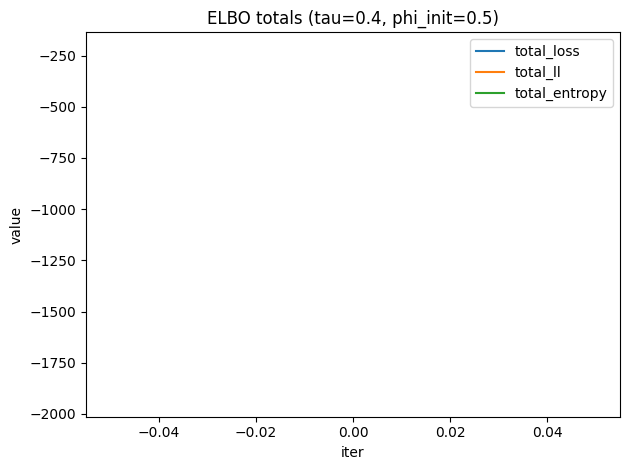

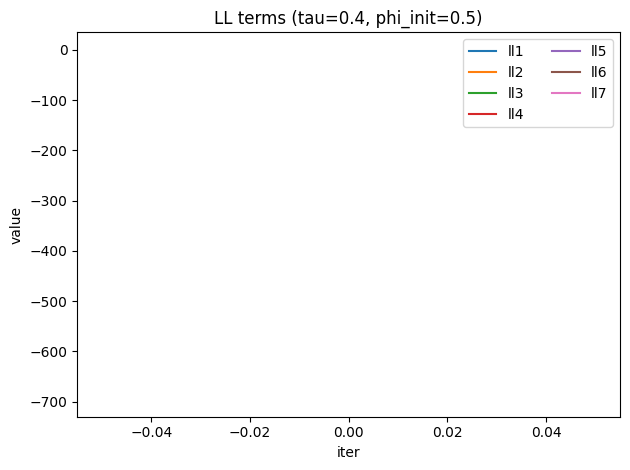

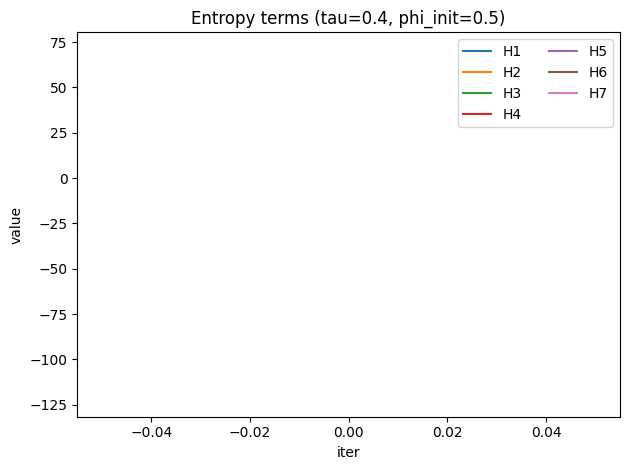

VI debug loop:   1%|          | 1/100 [00:22<37:56, 22.99s/it]


Iter 2/100 | mu_lambda_beta=7.3452 | sigmasq_lambda_beta=0.0295 | lambda_b1=1075.1917 | lambda_b2=3948.9087
  E[phi]=1.7070 | ||mu_W||=25.2481 | min_eig_VX=5.073e-02 | min_eig_VS=6.626e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1717.6205 | total_ll=-1553.2484 | total_entropy=-164.3721
  relative change in total_loss: 1.0925e+01


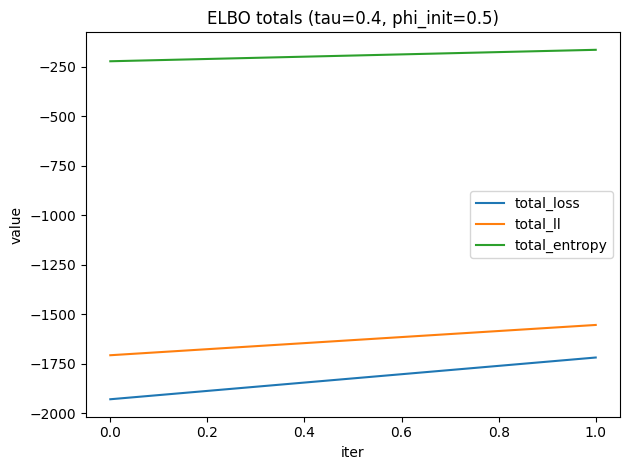

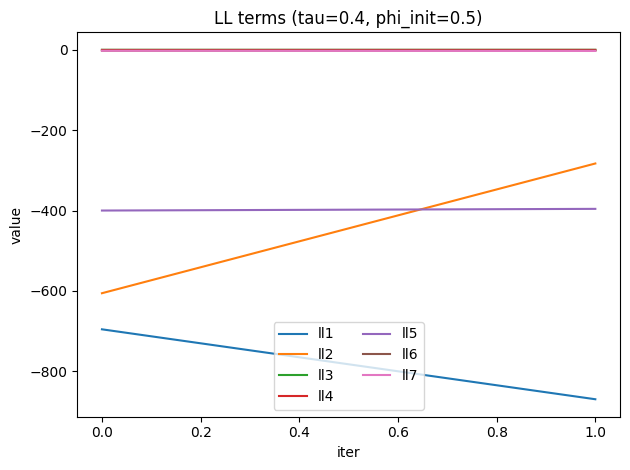

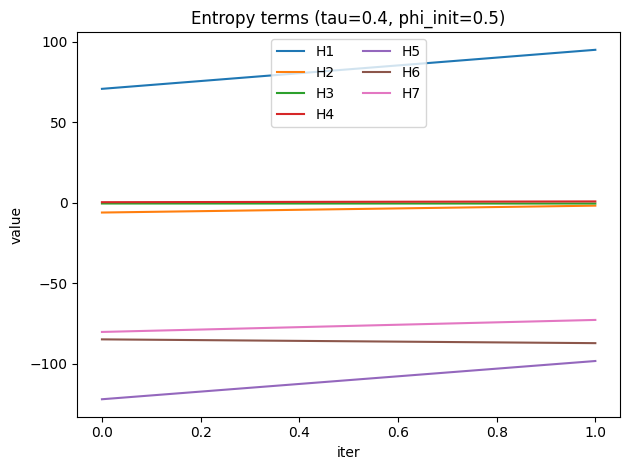

VI debug loop:   2%|▏         | 2/100 [00:46<37:40, 23.07s/it]


Iter 3/100 | mu_lambda_beta=7.3334 | sigmasq_lambda_beta=0.0473 | lambda_b1=1045.8627 | lambda_b2=3078.4805
  E[phi]=1.5598 | ||mu_W||=27.1025 | min_eig_VX=4.534e-02 | min_eig_VS=9.933e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1638.3517 | total_ll=-1453.9177 | total_entropy=-184.4340
  relative change in total_loss: 4.6150e+00


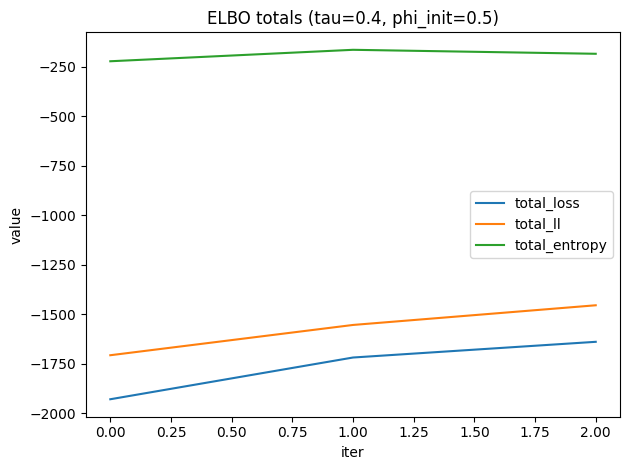

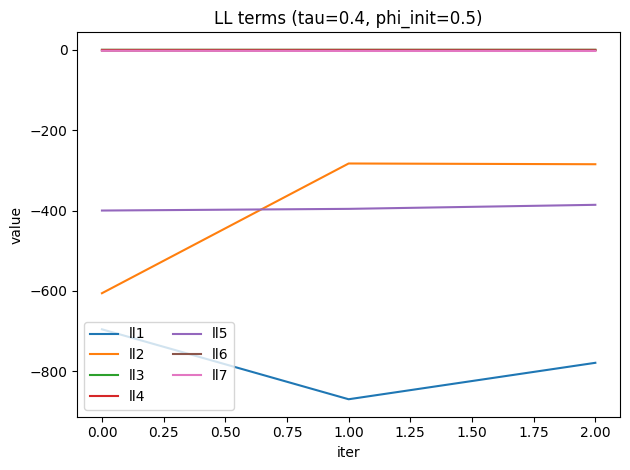

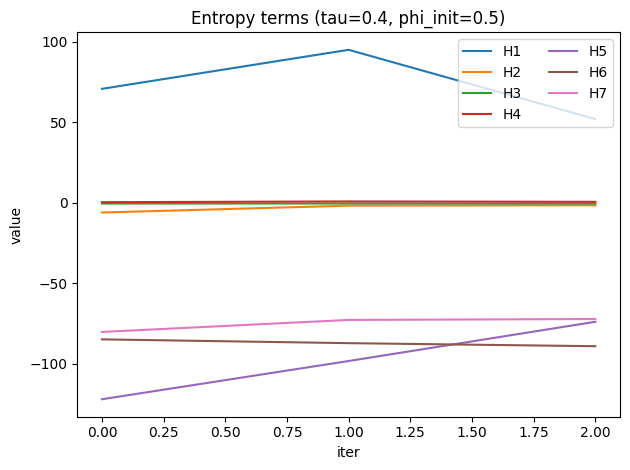

VI debug loop:   3%|▎         | 3/100 [01:09<37:31, 23.21s/it]


Iter 4/100 | mu_lambda_beta=7.5603 | sigmasq_lambda_beta=0.0363 | lambda_b1=1014.0200 | lambda_b2=2406.5176
  E[phi]=1.4429 | ||mu_W||=28.1265 | min_eig_VX=3.899e-02 | min_eig_VS=1.014e-01
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1590.4969 | total_ll=-1379.6122 | total_entropy=-210.8847
  relative change in total_loss: 2.9209e+00


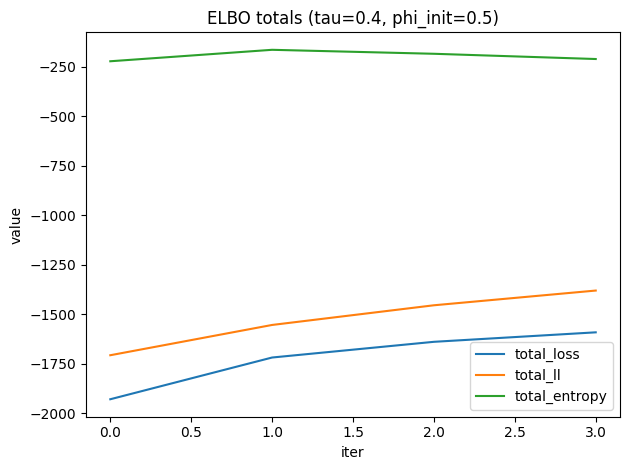

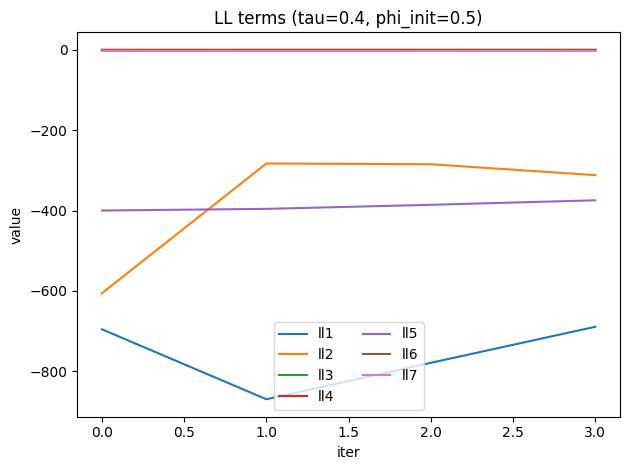

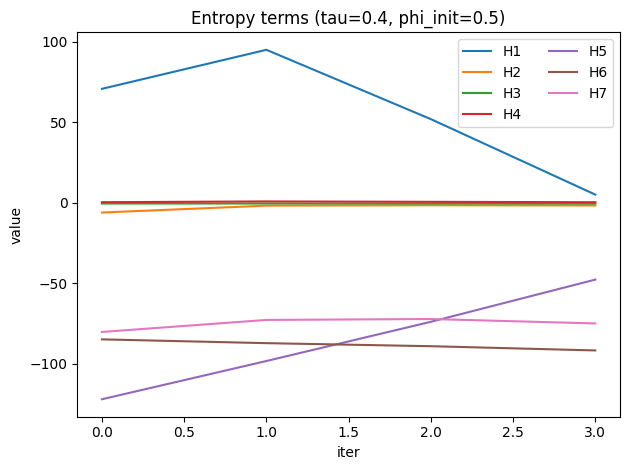

VI debug loop:   4%|▍         | 4/100 [01:33<37:41, 23.55s/it]


Iter 5/100 | mu_lambda_beta=7.7282 | sigmasq_lambda_beta=0.0281 | lambda_b1=968.5718 | lambda_b2=2062.7188
  E[phi]=1.3733 | ||mu_W||=29.1965 | min_eig_VX=2.825e-02 | min_eig_VS=8.731e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1570.5040 | total_ll=-1329.5073 | total_entropy=-240.9967
  relative change in total_loss: 1.2570e+00


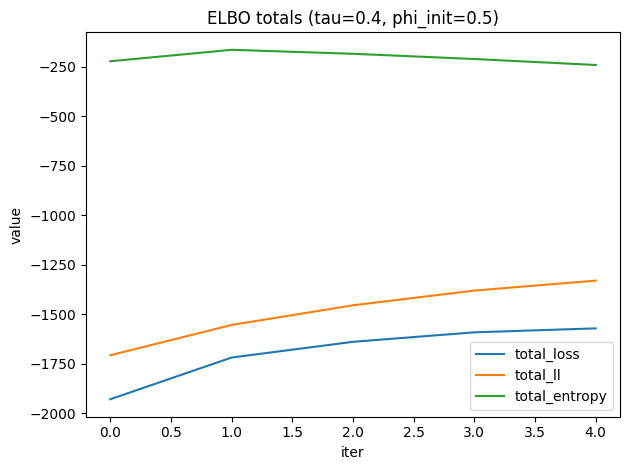

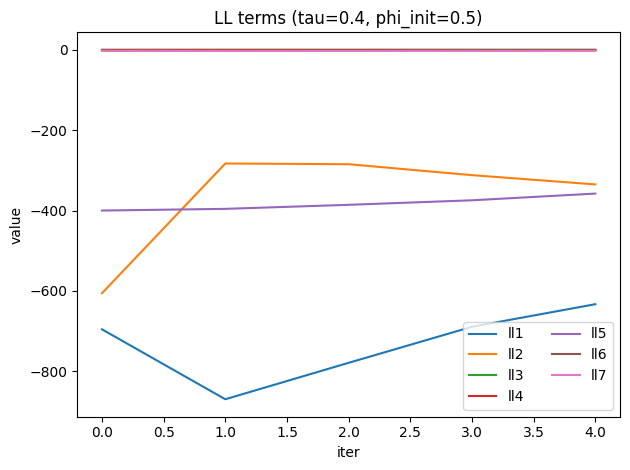

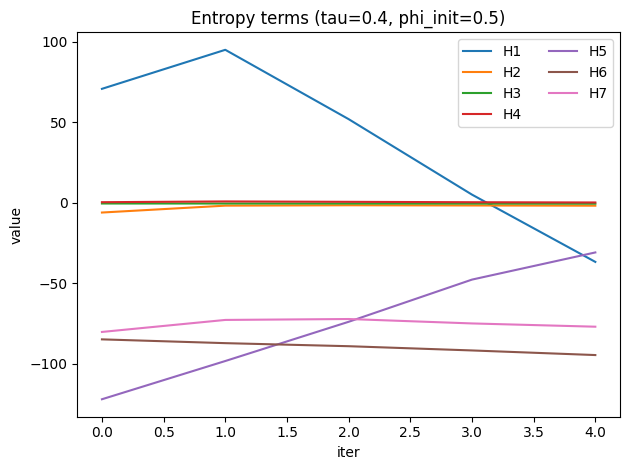

VI debug loop:   5%|▌         | 5/100 [01:57<37:27, 23.66s/it]


Iter 6/100 | mu_lambda_beta=7.8148 | sigmasq_lambda_beta=0.0239 | lambda_b1=917.1971 | lambda_b2=1901.4053
  E[phi]=1.3228 | ||mu_W||=29.8771 | min_eig_VX=2.402e-02 | min_eig_VS=7.819e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1555.5302 | total_ll=-1285.0563 | total_entropy=-270.4739
  relative change in total_loss: 9.5344e-01


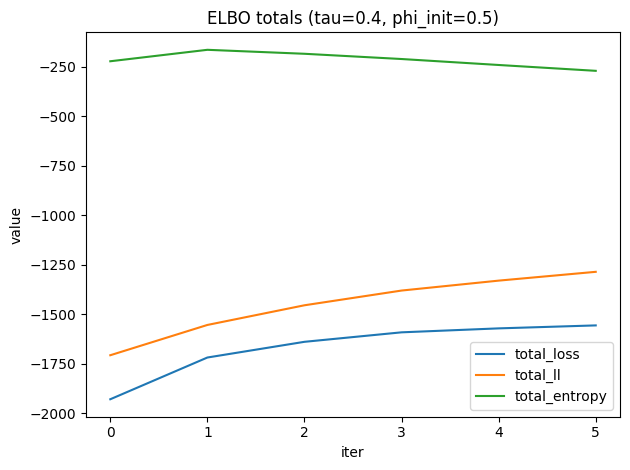

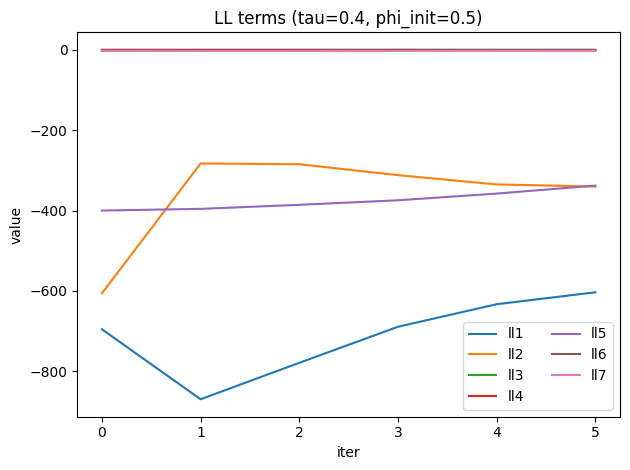

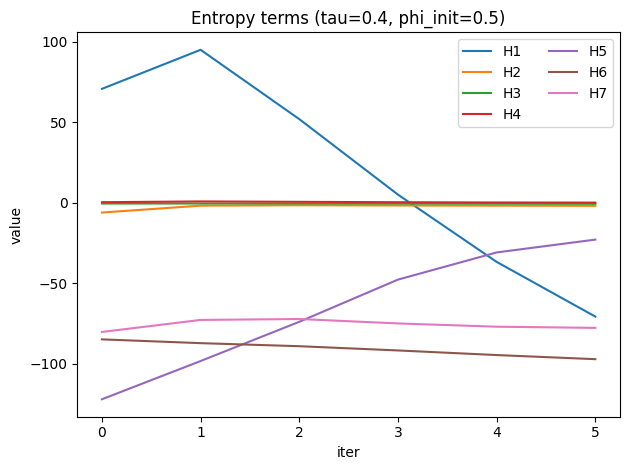

VI debug loop:   6%|▌         | 6/100 [02:21<37:24, 23.88s/it]


Iter 7/100 | mu_lambda_beta=7.8657 | sigmasq_lambda_beta=0.0220 | lambda_b1=876.1632 | lambda_b2=1780.9608
  E[phi]=1.2793 | ||mu_W||=30.5444 | min_eig_VX=2.079e-02 | min_eig_VS=7.455e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1541.8744 | total_ll=-1244.9102 | total_entropy=-296.9642
  relative change in total_loss: 8.7788e-01


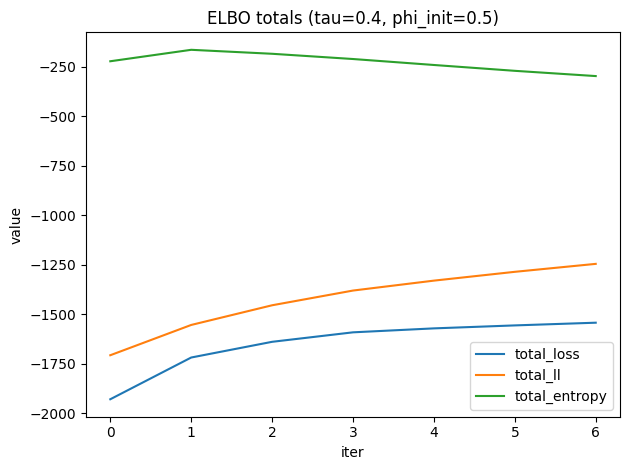

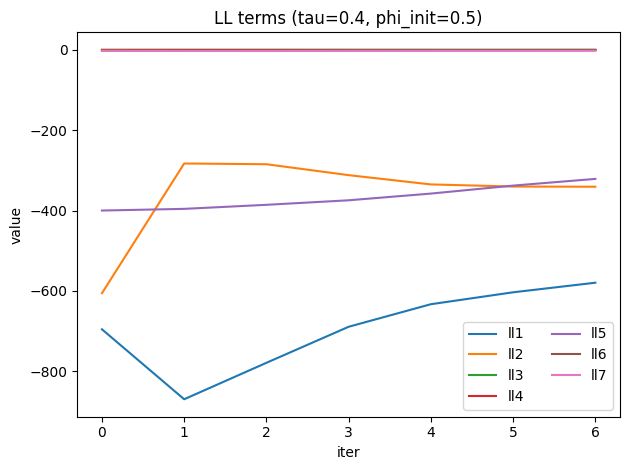

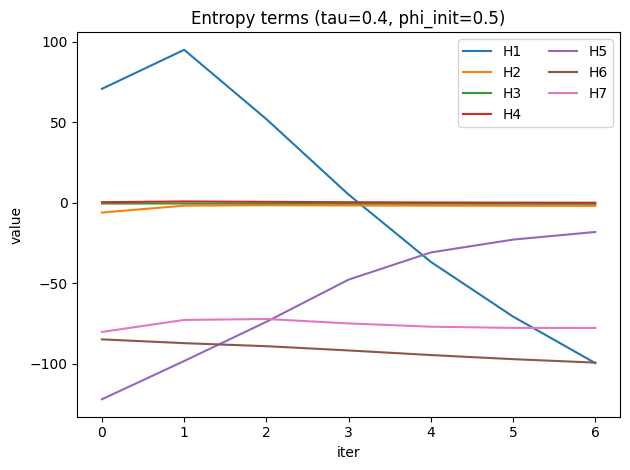

VI debug loop:   7%|▋         | 7/100 [02:45<36:43, 23.69s/it]


Iter 8/100 | mu_lambda_beta=7.8981 | sigmasq_lambda_beta=0.0205 | lambda_b1=848.9888 | lambda_b2=1670.7736
  E[phi]=1.2444 | ||mu_W||=31.3261 | min_eig_VX=1.842e-02 | min_eig_VS=7.444e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1529.7362 | total_ll=-1210.1469 | total_entropy=-319.5894
  relative change in total_loss: 7.8724e-01


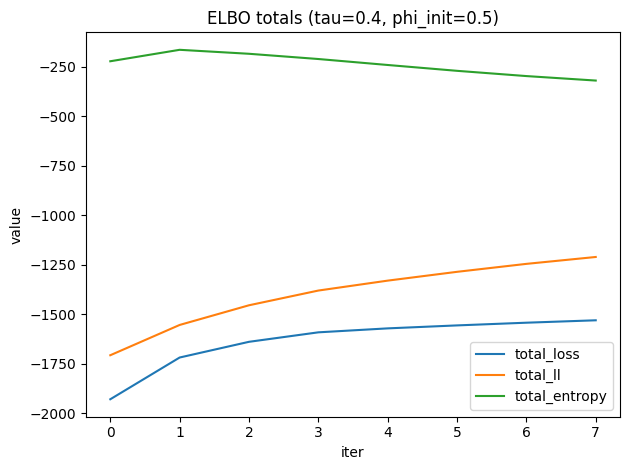

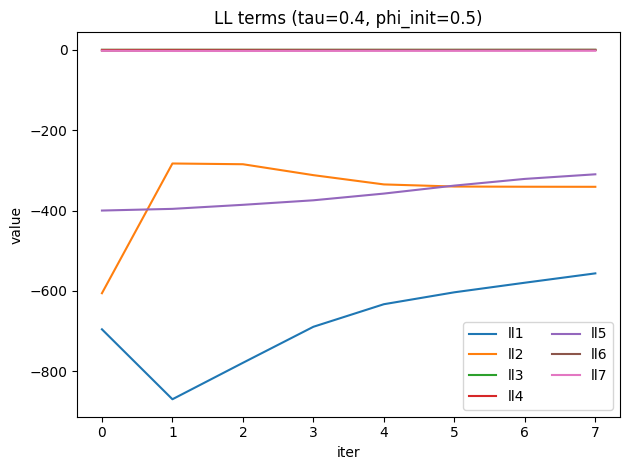

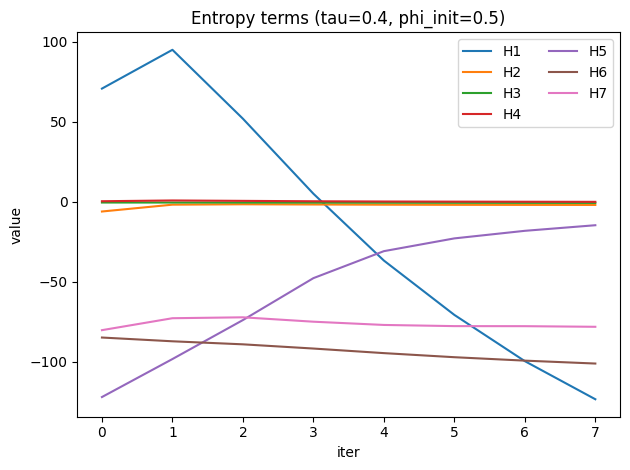

VI debug loop:   8%|▊         | 8/100 [03:08<36:14, 23.63s/it]


Iter 9/100 | mu_lambda_beta=7.9193 | sigmasq_lambda_beta=0.0192 | lambda_b1=832.7164 | lambda_b2=1568.2883
  E[phi]=1.2256 | ||mu_W||=32.1893 | min_eig_VX=1.663e-02 | min_eig_VS=7.301e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1519.1675 | total_ll=-1180.1635 | total_entropy=-339.0041
  relative change in total_loss: 6.9089e-01


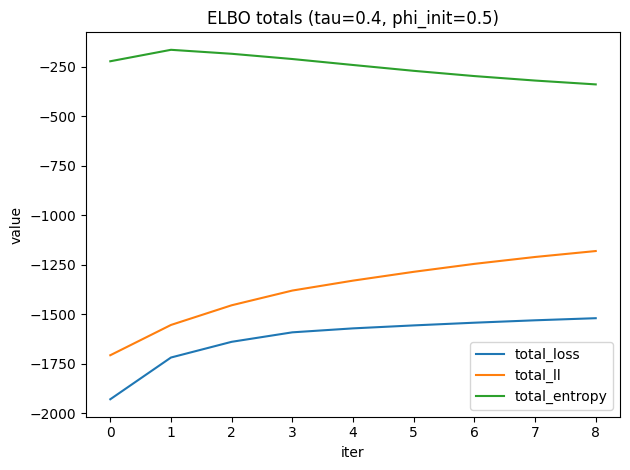

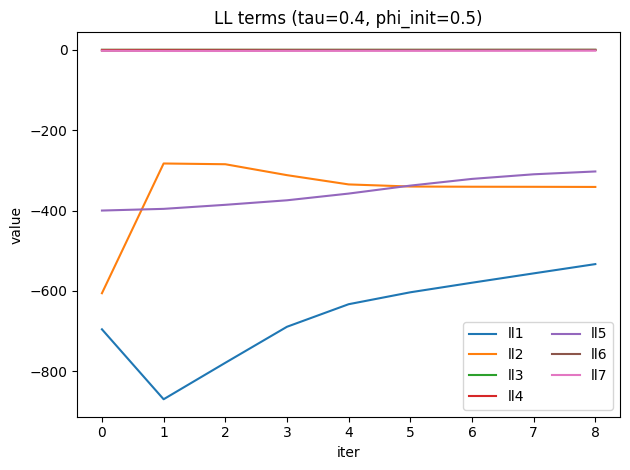

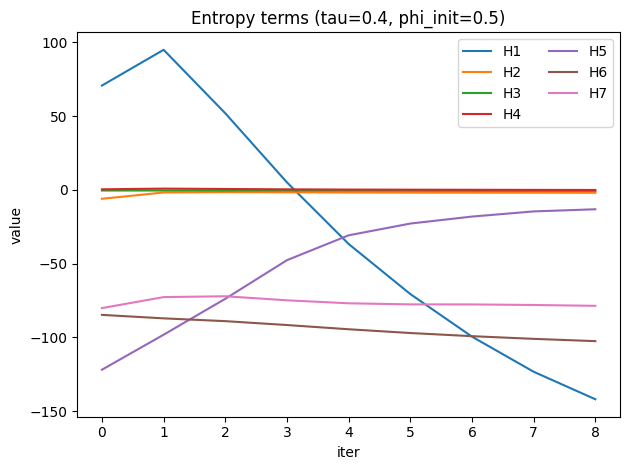

VI debug loop:   9%|▉         | 9/100 [03:32<35:50, 23.63s/it]


Iter 10/100 | mu_lambda_beta=7.9315 | sigmasq_lambda_beta=0.0181 | lambda_b1=823.0109 | lambda_b2=1473.6115
  E[phi]=1.2244 | ||mu_W||=33.0884 | min_eig_VX=1.524e-02 | min_eig_VS=6.963e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1511.0691 | total_ll=-1154.6453 | total_entropy=-356.4239
  relative change in total_loss: 5.3308e-01


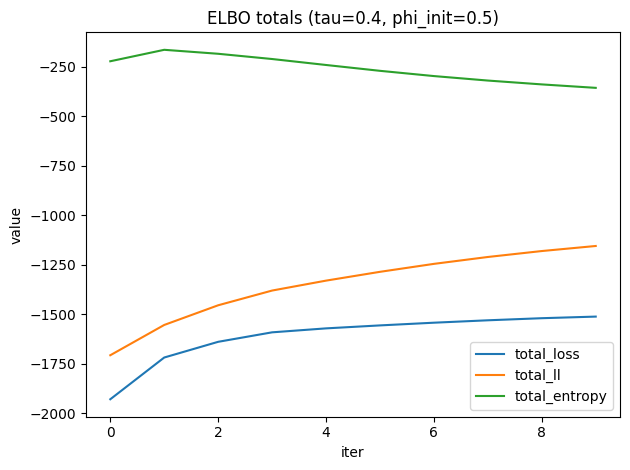

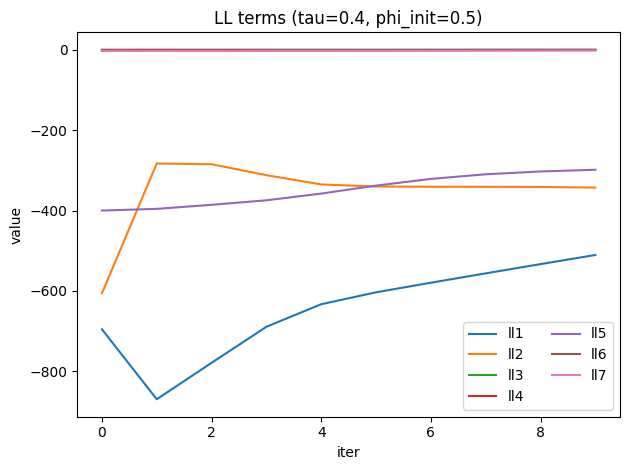

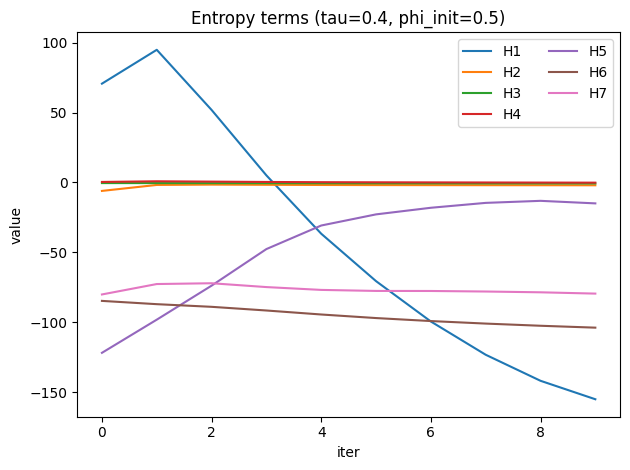

VI debug loop:  10%|█         | 10/100 [03:55<35:11, 23.46s/it]


Iter 11/100 | mu_lambda_beta=7.9381 | sigmasq_lambda_beta=0.0170 | lambda_b1=818.1460 | lambda_b2=1391.4777
  E[phi]=1.2384 | ||mu_W||=33.9219 | min_eig_VX=1.414e-02 | min_eig_VS=6.591e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1504.5782 | total_ll=-1133.3284 | total_entropy=-371.2498
  relative change in total_loss: 4.2955e-01


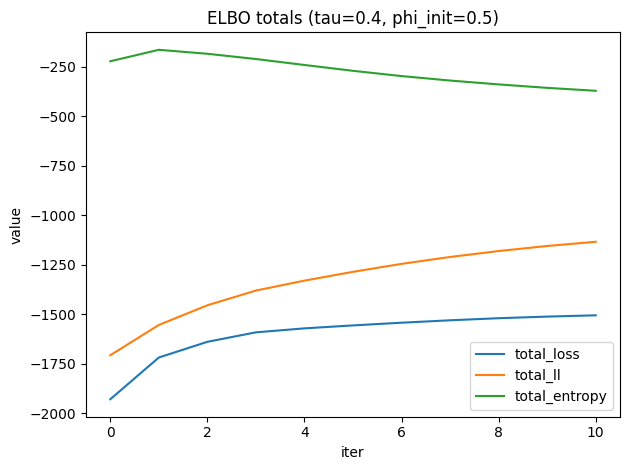

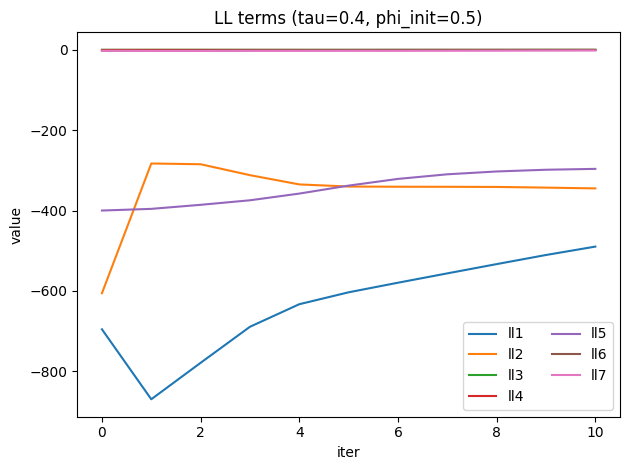

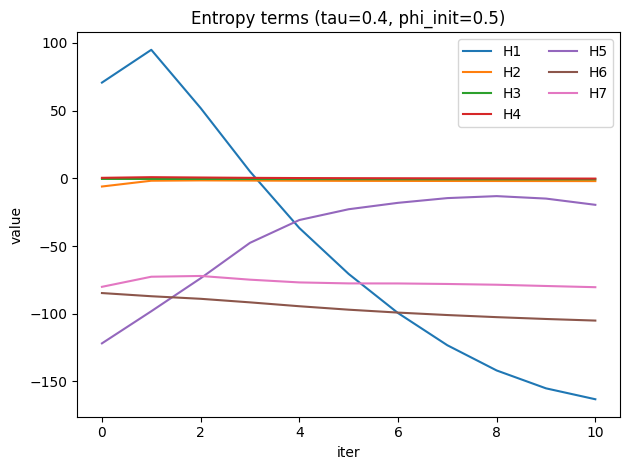

VI debug loop:  11%|█         | 11/100 [04:18<34:37, 23.34s/it]


Iter 12/100 | mu_lambda_beta=7.9409 | sigmasq_lambda_beta=0.0160 | lambda_b1=816.6316 | lambda_b2=1321.3795
  E[phi]=1.2710 | ||mu_W||=34.6811 | min_eig_VX=1.324e-02 | min_eig_VS=6.088e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1499.2838 | total_ll=-1115.4148 | total_entropy=-383.8690
  relative change in total_loss: 3.5189e-01


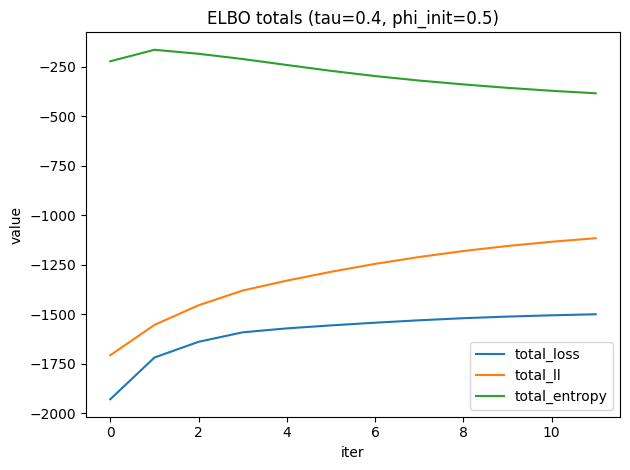

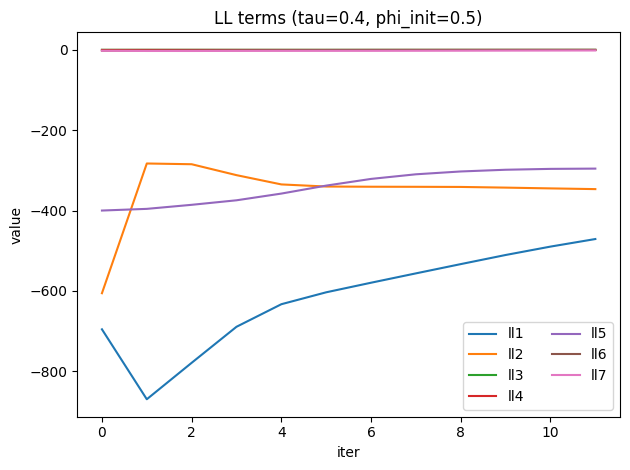

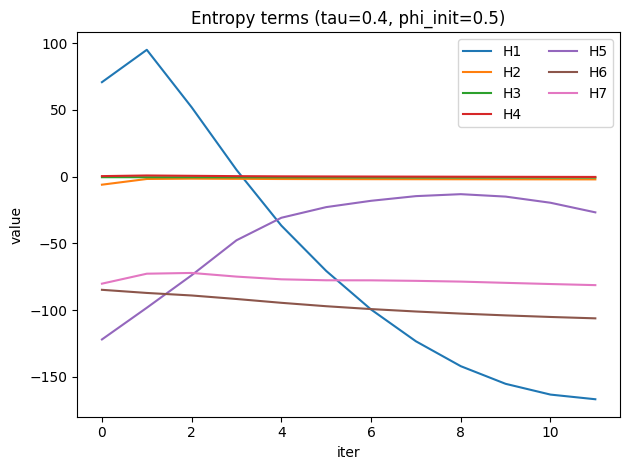

VI debug loop:  12%|█▏        | 12/100 [04:41<34:04, 23.23s/it]


Iter 13/100 | mu_lambda_beta=7.9428 | sigmasq_lambda_beta=0.0152 | lambda_b1=814.8823 | lambda_b2=1261.3231
  E[phi]=1.3235 | ||mu_W||=35.3939 | min_eig_VX=1.250e-02 | min_eig_VS=4.960e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1496.0312 | total_ll=-1099.9277 | total_entropy=-396.1036
  relative change in total_loss: 2.1694e-01


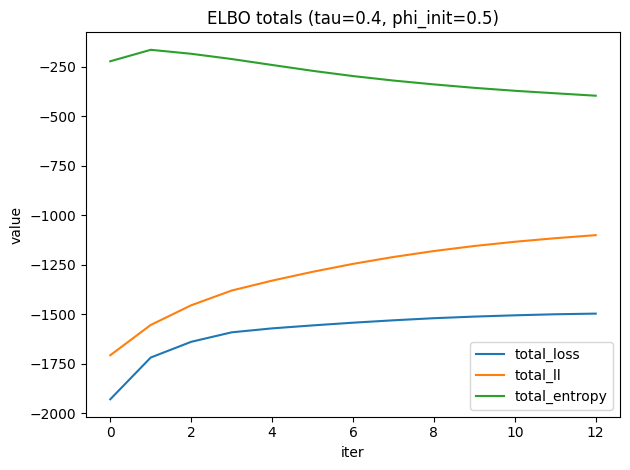

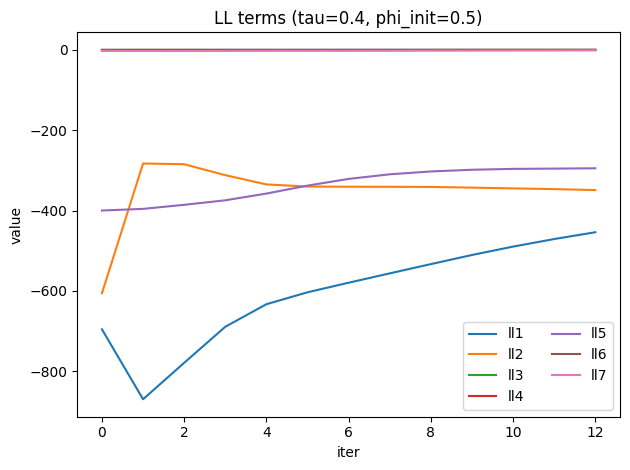

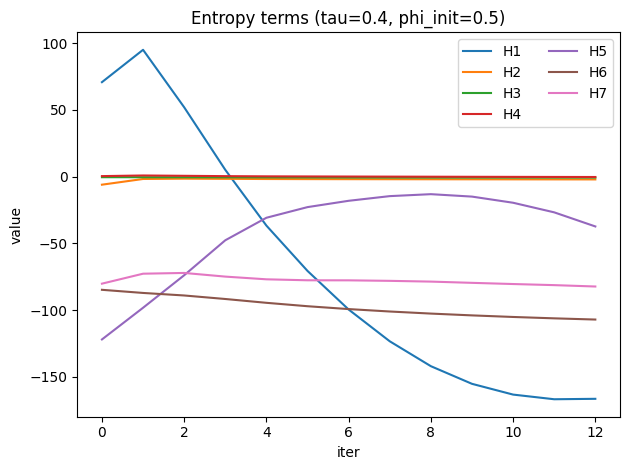

VI debug loop:  13%|█▎        | 13/100 [05:04<33:32, 23.13s/it]


Iter 14/100 | mu_lambda_beta=7.9450 | sigmasq_lambda_beta=0.0145 | lambda_b1=810.3994 | lambda_b2=1212.3300
  E[phi]=1.3763 | ||mu_W||=35.9747 | min_eig_VX=1.189e-02 | min_eig_VS=4.419e-02
  correct piX entries: 6
  correct piS entries: 6
[ELBO] total_loss=-1494.5052 | total_ll=-1086.6151 | total_entropy=-407.8901
  relative change in total_loss: 1.0200e-01


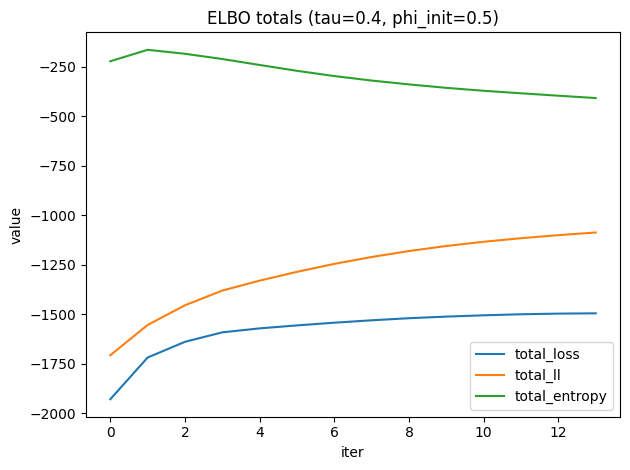

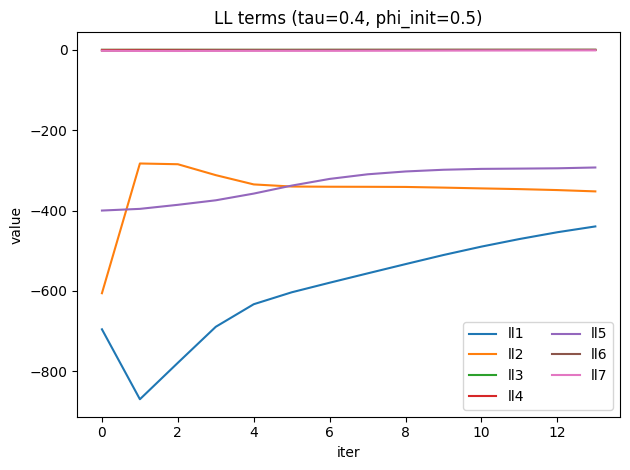

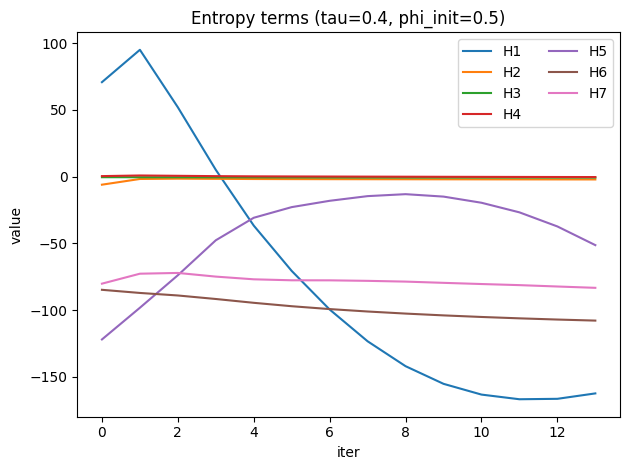

VI debug loop:  13%|█▎        | 13/100 [05:27<36:29, 25.16s/it]

Stopping: relative change in loss is 1.0200e-01%


In [ ]:
# ============================================================
# NOTEBOOK CELL: VI core loop + ELBO term debugging (NO funcs)
# Paste/run AFTER your data-load cell that defines:
#   X, Y, Dist, n_blocks, n_locations, device,
#   perm_matrix_x, perm_matrix_s, prior_parameters
# ============================================================

import numpy as np
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm

from revised_elbo import vi_piX, vi_piS
from utils import nearest_pd_torch, compute_q_phi, round_to_perm

# -----------------------
# User-tunable knobs
# -----------------------
n_iter = 100

tau_X = 0.4
tau_S = 0.4

phi_init = 0.5
n_steps = 50
n_phi_samples = 120
n_piX_sample = 50
n_piS_sample = 50

lr_piX = 0.01
lr_piS = 0.01

VX_ub = 0.6
VS_ub = 0.6

plot_every = 1   # set 5/10 if too slow
seed = 522
torch.manual_seed(seed)

# -----------------------
# Switches (edit freely)
# -----------------------
fix_piX = False
fix_piS = False
fix_mu_lambda_beta = False
fix_sigmasq_lambda_beta = False
fix_lambda_b1 = False
fix_lambda_b2 = False
fix_mu_W = False
fix_Sigma_W = False
fix_mean_Rphi_inv = False

# -----------------------
# Priors (from your dict)
# -----------------------
a1 = prior_parameters["a1"]
b1 = prior_parameters["b1"]
a2 = prior_parameters["a2"]
b2 = prior_parameters["b2"]
eta_X_sq = prior_parameters["eta_X_sq"]
eta_S_sq = prior_parameters["eta_S_sq"]
mu_beta = prior_parameters["mu_beta"]
sigmasq_beta = prior_parameters["sigmasq_beta"]
phi_prior_lb = torch.as_tensor(prior_parameters["phi_prior_lb"], device=device)
phi_prior_ub = torch.as_tensor(prior_parameters["phi_prior_ub"], device=device)

# -----------------------
# Fixed defaults (only used if fix_* = True)
# -----------------------
mu_lambda_beta_fixed = torch.tensor(0.1, device=device)
sigmasq_lambda_beta_fixed = torch.tensor(0.1, device=device)

# your example: ((B*n_i)*0.5 + 0.1)*5
lambda_b1_fixed = torch.tensor(((n_blocks * n_locations) * 0.5 + 0.1) * 5.0, device=device)
lambda_b2_fixed = torch.tensor(0.5, device=device)

M_X_star_fixed = perm_matrix_x.T
M_S_star_fixed = perm_matrix_s.T
V_X_star_fixed = torch.eye(n_locations, n_locations, device=device)
V_S_star_fixed = torch.eye(n_locations, n_locations, device=device)

mean_Rphi_inv_fixed = torch.linalg.inv(torch.exp(-phi_init * Dist))

# -----------------------
# Initialize state
# -----------------------
mu_lambda_beta = torch.tensor(0.1, device=device)
sigmasq_lambda_beta = torch.tensor(0.1, device=device)

mu_W = torch.zeros(n_blocks, n_locations, device=device)
Sigma_W = torch.eye(n_blocks * n_locations, device=device)

Rphi = torch.exp(-(phi_init) * Dist)
mean_Rphi_inv = torch.linalg.inv(nearest_pd_torch(Rphi, epsilon=0.01)).to(device)

lambda_a1 = n_blocks * n_locations * 0.5 + a1
lambda_b1 = torch.tensor(0.5, device=device)
lambda_a2 = n_blocks * n_locations * 0.5 + a2
lambda_b2 = torch.tensor(0.5, device=device)

# -----------------------
# Initialize pi models + opt
# -----------------------
model_piX = vi_piX(n_locations=n_locations).to(device)
model_piS = vi_piS(n_locations=n_locations, n_blocks=n_blocks).to(device)

M_X_star = model_piX.current_M_X_star.clone().data.to(device)
V_X_star = model_piX.current_V_X_star.clone().data.to(device)
M_S_star = model_piS.current_M_S_star.clone().data.to(device)
V_S_star = model_piS.current_V_S_star.clone().data.to(device)

# Start from the true perms (as in your call example)
M_X_star = M_X_star_fixed.clone()
M_S_star = M_S_star_fixed.clone()
V_X_star = V_X_star_fixed.clone()
V_S_star = V_S_star_fixed.clone()

optimizer_piX = optim.AdamW(model_piX.parameters(), lr=lr_piX, weight_decay=1e-2)
optimizer_piS = optim.AdamW(model_piS.parameters(), lr=lr_piS, weight_decay=1e-2)

# logits matrices for entropy 6/7 (overwritten if pi models update)
V_X = torch.zeros(n_locations, n_locations, device=device)
V_S = torch.zeros(n_locations, n_locations, device=device)

# true perms for correctness printing
pi_X_true = perm_matrix_x.T
pi_S_true = perm_matrix_s.T

# -----------------------
# ELBO storage arrays
# -----------------------
def _nanvec():
    return np.full(n_iter, np.nan, dtype=np.float64)

elbo = {
    "ll1": _nanvec(), "ll2": _nanvec(), "ll3": _nanvec(), "ll4": _nanvec(),
    "ll5": _nanvec(), "ll6": _nanvec(), "ll7": _nanvec(), "total_ll": _nanvec(),
    "H1": _nanvec(), "H2": _nanvec(), "H3": _nanvec(), "H4": _nanvec(),
    "H5": _nanvec(), "H6": _nanvec(), "H7": _nanvec(), "total_entropy": _nanvec(),
    "total_loss": _nanvec(),
}

# optional extra diagnostics to spot blowups
diag = {
    "mean_phi": _nanvec(),
    "mean_log_q_phi": _nanvec(),
    "min_eig_VX_minus_MtM": _nanvec(),
    "min_eig_VS_minus_MtM": _nanvec(),
    "muW_norm": _nanvec(),
    "SigmaW_logdet": _nanvec(),
}

# -----------------------
# Plot helper (inline)
# -----------------------
def _plot_elbo(upto, suffix=""):
    k = upto + 1

    plt.figure()
    plt.plot(elbo["total_loss"][:k], label="total_loss")
    plt.plot(elbo["total_ll"][:k], label="total_ll")
    plt.plot(elbo["total_entropy"][:k], label="total_entropy")
    plt.legend()
    plt.title(f"ELBO totals {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    plt.figure()
    for nm in ["ll1","ll2","ll3","ll4","ll5","ll6","ll7"]:
        plt.plot(elbo[nm][:k], label=nm)
    plt.legend(ncol=2)
    plt.title(f"LL terms {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()

    plt.figure()
    for nm in ["H1","H2","H3","H4","H5","H6","H7"]:
        plt.plot(elbo[nm][:k], label=nm)
    plt.legend(ncol=2)
    plt.title(f"Entropy terms {suffix}")
    plt.xlabel("iter")
    plt.ylabel("value")
    plt.tight_layout()
    plt.show()


# IMPORTANT: separate prev_loss for each inner optimizer loop
prev_loss_piX = None
prev_loss_piS = None

# ============================================================
# MAIN VI LOOP (step-by-step; you can interrupt any time)
# ============================================================
for it in tqdm(range(n_iter), desc="VI debug loop"):
    # -----------------------
    # sigmasq_lambda_beta
    # -----------------------
    if not fix_sigmasq_lambda_beta:
        X_V_X_star_X = torch.einsum("bi,ij,bj->b", X, V_X_star, X).sum()
        sigmasq_lambda_beta = 1.0 / (((lambda_a2 * X_V_X_star_X) / lambda_b2) + (1.0 / sigmasq_beta))
    else:
        sigmasq_lambda_beta = sigmasq_lambda_beta_fixed

    # -----------------------
    # mu_lambda_beta
    # -----------------------
    if not fix_mu_lambda_beta:
        residual = Y - (M_S_star @ mu_W.T).T
        X_M_X_star_residual = torch.einsum("bi,ij,bj->b", X, M_X_star.T, residual).sum()
        mu_lambda_beta = sigmasq_lambda_beta * ((lambda_a2 / lambda_b2) * X_M_X_star_residual + mu_beta / sigmasq_beta)
    else:
        mu_lambda_beta = mu_lambda_beta_fixed

    # -----------------------
    # lambda_b1
    # -----------------------
    if not fix_lambda_b1:
        mu_W_flat = mu_W.flatten()
        V_W = Sigma_W + torch.outer(mu_W_flat, mu_W_flat)
        lambda_b1 = 0.5 * (torch.trace(mean_Rphi_inv @ V_W)) + b1
    else:
        lambda_b1 = lambda_b1_fixed

    # -----------------------
    # lambda_b2 (+ eigen diagnostics)
    # -----------------------
    if not fix_lambda_b2:
        res = Y - mu_lambda_beta * (M_X_star @ X.T).T - (M_S_star @ mu_W.T).T
        term = torch.trace(res.T @ res)
        term = term + mu_lambda_beta ** 2 * torch.trace(X @ (V_X_star - M_X_star.T @ M_X_star) @ X.T)
        min_eig_VX = torch.min(torch.linalg.eigvalsh(V_X_star - M_X_star.T @ M_X_star))
        term = term + sigmasq_lambda_beta * torch.trace(X @ V_X_star @ X.T)
        term = term + torch.trace(mu_W @ (V_S_star - M_S_star.T @ M_S_star) @ mu_W.T)
        min_eig_VS = torch.min(torch.linalg.eigvalsh(V_S_star - M_S_star.T @ M_S_star))
        term = term + torch.trace(torch.block_diag(*[V_S_star] * n_blocks) @ Sigma_W)
        lambda_b2 = 0.5 * term + b2
    else:
        min_eig_VX = torch.tensor(float("nan"), device=device)
        min_eig_VS = torch.tensor(float("nan"), device=device)
        lambda_b2 = lambda_b2_fixed

    # -----------------------
    # Sigma_W
    # -----------------------
    if not fix_Sigma_W:
        term1 = (lambda_a2 / lambda_b2) * torch.block_diag(*[V_S_star] * n_blocks)
        term2 = (lambda_a1 / lambda_b1) * mean_Rphi_inv
        Sigma_W_inv = term1 + term2
        Sigma_W_inv = (Sigma_W_inv + Sigma_W_inv.T) / 2
        eigvals, eigvecs = torch.linalg.eigh(Sigma_W_inv)
        eigvals_clamped = torch.clamp(eigvals, min=1e-3)
        Sigma_W = eigvecs @ torch.diag(1/eigvals_clamped) @ eigvecs.T
        #Sigma_W = torch.linalg.pinv(Sigma_W_inv, hermitian=True, rtol=1e-4)
        Sigma_W = (Sigma_W + Sigma_W.T) / 2

    # -----------------------
    # mu_W
    # -----------------------
    if not fix_mu_W:
        mu_W = (lambda_a2 / lambda_b2) * (
            Sigma_W @ (M_S_star.T @ Y.T - mu_lambda_beta * M_S_star.T @ M_X_star @ X.T).T.flatten()
        ).reshape(n_blocks, n_locations)

    # -----------------------
    # mean_Rphi_inv (importance sampling)
    # -----------------------
    if not fix_mean_Rphi_inv:
        phi_samples = torch.rand(n_phi_samples, device=device) * (phi_prior_ub - phi_prior_lb) + phi_prior_lb
        q_phi_values = [compute_q_phi(phi, Dist, mu_W, Sigma_W, lambda_a1, lambda_b1) for phi in phi_samples]
        logits = torch.tensor([q_phi_values[i][0] for i in range(n_phi_samples)], device=device)
        w = torch.nn.functional.softmax(logits, dim=0)

        Rphi_inv_sum = torch.zeros_like(Dist)
        phi_sum = torch.tensor(0.0, device=device)
        w_sum = torch.tensor(0.0, device=device)
        log_q_sum = torch.tensor(0.0, device=device)

        for i in range(n_phi_samples):
            if w[i] > 1e-5:
                Rphi_inv_sum = Rphi_inv_sum + w[i] * q_phi_values[i][1]
                w_sum = w_sum + w[i]
                phi_sum = phi_sum + w[i] * phi_samples[i]
                log_q_sum = log_q_sum + w[i] * q_phi_values[i][0]

        mean_Rphi_inv = Rphi_inv_sum / w_sum
        mean_phi = phi_sum / w_sum
        mean_log_q_phi = log_q_sum / w_sum
        #calculate normalizing constant for q_phi 
        log_q = torch.tensor([q_phi_values[x][0] for x in range(n_phi_samples)],
                    device=Dist.device, dtype=Dist.dtype)

        # sort by phi for trapezoid rule
        phi_sorted, idx = torch.sort(phi_samples)
        log_q_sorted = log_q[idx]

        # compute log f = log(exp(log_q)) = log_q, but stabilize exp via log-sum-exp shift
        m = torch.max(log_q_sorted)
        f_shifted = torch.exp(log_q_sorted - m)   # proportional to exp(log_q)

        # trapezoid integration on irregular grid
        dphi = phi_sorted[1:] - phi_sorted[:-1]   # (n-1,)
        trap_int_shifted = torch.sum(0.5 * (f_shifted[:-1] + f_shifted[1:]) * dphi)

        # normalizing constant estimate (and its log)
        Z_trap = trap_int_shifted * torch.exp(m)
        logZ_trap = torch.log(trap_int_shifted + 1e-30) + m
    else:
        mean_Rphi_inv = mean_Rphi_inv_fixed
        mean_phi = torch.tensor(phi_init, device=device)
        mean_log_q_phi = torch.tensor(0.0, device=device)
        logZ_trap = torch.tensor(0.0, device=device)

    # -----------------------
    # piX update
    # -----------------------
    if not fix_piX:
        prev = prev_loss_piX
        for step in range(n_steps):
            optimizer_piX.zero_grad()
            loss_piX = model_piX(
                Y, X, mu_lambda_beta, sigmasq_lambda_beta, M_S_star, mu_W,
                eta_X_sq, lambda_a2, lambda_b2, tau_X,
                n_piX_sample, VX_ub=VX_ub, seed=seed
            )
            loss_piX.backward()
            optimizer_piX.step()
            if prev is not None and abs(prev - loss_piX.item()) < 1e-4:
                break
            prev = loss_piX.item()
        prev_loss_piX = prev

        M_X_star = model_piX.current_M_X_star.clone().data
        V_X_star = model_piX.current_V_X_star.clone().data
        V_X = model_piX.VX.clone().data
    else:
        M_X_star = M_X_star_fixed
        V_X_star = V_X_star_fixed
        V_X = torch.zeros(n_locations, n_locations, device=device)

    # -----------------------
    # piS update
    # -----------------------
    if not fix_piS:
        prev = prev_loss_piS
        for step in range(n_steps):
            optimizer_piS.zero_grad()
            loss_piS = model_piS(
                Y, X, mu_lambda_beta, M_X_star, lambda_a2, lambda_b2,
                mu_W, Sigma_W, eta_S_sq, tau_S,
                n_piS_sample, VS_ub=VS_ub, seed=seed
            )
            loss_piS.backward()
            optimizer_piS.step()
            if prev is not None and abs(prev - loss_piS.item()) < 1e-4:
                break
            prev = loss_piS.item()
        prev_loss_piS = prev

        M_S_star = model_piS.current_M_S_star.clone().data
        V_S_star = model_piS.current_V_S_star.clone().data
        V_S = model_piS.VS.clone().data
    else:
        M_S_star = M_S_star_fixed
        V_S_star = V_S_star_fixed
        V_S = torch.zeros(n_locations, n_locations, device=device)

    # -----------------------
    # Print iteration summary
    # -----------------------
    print(
        f"\nIter {it+1}/{n_iter} | mu_lambda_beta={mu_lambda_beta.item():.4f} "
        f"| sigmasq_lambda_beta={sigmasq_lambda_beta.item():.4f} "
        f"| lambda_b1={lambda_b1.item():.4f} | lambda_b2={lambda_b2.item():.4f}"
    )
    print(
        f"  E[phi]={mean_phi.item():.4f} | ||mu_W||={torch.norm(mu_W).item():.4f} "
        f"| min_eig_VX={min_eig_VX.item():.3e} | min_eig_VS={min_eig_VS.item():.3e}"
    )

    # permutation diagnostics
    try:
        est_perm_piX = round_to_perm(M_X_star.detach().cpu().numpy())
        correct_x = torch.sum(torch.tensor(est_perm_piX, device=device) * pi_X_true)
        print(f"  correct piX entries: {int(correct_x.item())}")
    except Exception:
        pass

    try:
        est_perm_piS = round_to_perm(M_S_star.detach().cpu().numpy())
        correct_s = torch.sum(torch.tensor(est_perm_piS, device=device) * pi_S_true)
        print(f"  correct piS entries: {int(correct_s.item())}")
    except Exception:
        pass

    # ============================================================
    # ELBO DEBUG (store terms each iteration)
    # ============================================================
    elbo_ll_term1 = - (a2 + 0.5 * (n_blocks * n_locations) + 1) * (
        torch.log(torch.as_tensor(lambda_b2, device=device)) - torch.digamma(torch.as_tensor(lambda_a2, device=device))
    )

    resid = Y - mu_lambda_beta * (M_X_star @ X.T).T - (M_S_star @ mu_W.T).T
    resid_sq = torch.trace(resid.T @ resid)
    resid_sq = resid_sq + mu_lambda_beta ** 2 * torch.trace(X @ (V_X_star - M_X_star.T @ M_X_star) @ X.T)
    resid_sq = resid_sq + sigmasq_lambda_beta * torch.trace(X @ V_X_star @ X.T)
    resid_sq = resid_sq + torch.trace(mu_W @ (V_S_star - M_S_star.T @ M_S_star) @ mu_W.T)
    resid_sq = resid_sq + torch.trace(torch.block_diag(*[V_S_star] * n_blocks) @ Sigma_W)

    elbo_ll_term2 = - (b2 + 0.5 * resid_sq) * (lambda_a2 / lambda_b2)
    elbo_ll_term3 = - (b1 * lambda_a1) / lambda_b1
    elbo_ll_term4 = - (mu_lambda_beta ** 2 + sigmasq_lambda_beta) / (2 * sigmasq_beta)
    elbo_ll_term5= -(a1 + 0.5 * (n_blocks * n_locations) + 1) * (torch.log(torch.as_tensor(lambda_b1, device=device)) - torch.digamma(torch.as_tensor(lambda_a1, device=device)))

    elbo_ll_term6 = model_piX.mean_log_term_sum
    elbo_ll_term7 = model_piS.mean_log_term_sum
    total_ll = elbo_ll_term1 + elbo_ll_term2 + elbo_ll_term3 + elbo_ll_term4 + elbo_ll_term5 + elbo_ll_term6 + elbo_ll_term7

    entropy_term1 = 0.5 * torch.slogdet(Sigma_W)[1]
    entropy_term2 = 0.5 * torch.log(torch.as_tensor(sigmasq_lambda_beta, device=device))

    entropy_term3 = (
        lambda_a1 + torch.log(torch.as_tensor(lambda_b1, device=device)) + torch.lgamma(torch.as_tensor(lambda_a1, device=device))
        - (1 + lambda_a1) * torch.digamma(torch.as_tensor(lambda_a1, device=device))
    )
    entropy_term4 = (
        lambda_a2 + torch.log(torch.as_tensor(lambda_b2, device=device)) + torch.lgamma(torch.as_tensor(lambda_a2, device=device))
        - (1 + lambda_a2) * torch.digamma(torch.as_tensor(lambda_a2, device=device))
    )
    entropy_term5 = logZ_trap

    entropy_term6 = (n_locations ** 2) * (torch.log(torch.as_tensor(tau_X, device=device))) + 0.5 * torch.log(torch.special.expit(V_X) * (VX_ub - 0.01) + 0.01).sum()
    entropy_term7 = (n_locations ** 2) * ( torch.log(torch.as_tensor(tau_S, device=device))) + 0.5 * torch.log(torch.special.expit(V_S) * (VS_ub - 0.01) + 0.01).sum()
    

    total_entropy = entropy_term1 + entropy_term2 + entropy_term3 + entropy_term4 + entropy_term5 + entropy_term6 + entropy_term7
    total_loss = total_ll + total_entropy

    print(f"[ELBO] total_loss={total_loss.item():.4f} | total_ll={total_ll.item():.4f} | total_entropy={total_entropy.item():.4f}")

    # store ELBO pieces
    elbo["ll1"][it] = float(elbo_ll_term1.detach().cpu().item())
    elbo["ll2"][it] = float(elbo_ll_term2.detach().cpu().item())
    elbo["ll3"][it] = float(elbo_ll_term3.detach().cpu().item())
    elbo["ll4"][it] = float(elbo_ll_term4.detach().cpu().item())
    elbo["ll5"][it] = float(elbo_ll_term5.detach().cpu().item())    
    elbo["ll6"][it] = float(elbo_ll_term6.detach().cpu().item())
    elbo["ll7"][it] = float(elbo_ll_term7.detach().cpu().item())
    elbo["total_ll"][it] = float(total_ll.detach().cpu().item())

    elbo["H1"][it] = float(entropy_term1.detach().cpu().item())
    elbo["H2"][it] = float(entropy_term2.detach().cpu().item())
    elbo["H3"][it] = float(entropy_term3.detach().cpu().item())
    elbo["H4"][it] = float(entropy_term4.detach().cpu().item())
    elbo["H5"][it] = float(entropy_term5.detach().cpu().item())
    elbo["H6"][it] = float(entropy_term6.detach().cpu().item())
    elbo["H7"][it] = float(entropy_term7.detach().cpu().item())
    elbo["total_entropy"][it] = float(total_entropy.detach().cpu().item())

    elbo["total_loss"][it] = float(total_loss.detach().cpu().item())
    # relative change in percentage (with small epsilon to avoid div by zero)
    if it > 0:
        rel_change = (total_loss.detach().cpu().item() - elbo["total_loss"][it-1]) / (abs(elbo["total_loss"][it-1]) + 1e-8) * 100
        print(f"  relative change in total_loss: {rel_change:.4e}")

    # store diagnostics
    diag["mean_phi"][it] = float(mean_phi.detach().cpu().item())
    diag["mean_log_q_phi"][it] = float(mean_log_q_phi.detach().cpu().item())
    diag["min_eig_VX_minus_MtM"][it] = float(min_eig_VX.detach().cpu().item())
    diag["min_eig_VS_minus_MtM"][it] = float(min_eig_VS.detach().cpu().item())
    diag["muW_norm"][it] = float(torch.norm(mu_W).detach().cpu().item())
    try:
        diag["SigmaW_logdet"][it] = float(torch.slogdet(Sigma_W)[1].detach().cpu().item())
    except Exception:
        diag["SigmaW_logdet"][it] = np.nan

    # plot
    if plot_every and ((it % plot_every) == 0 or it == n_iter - 1):
        _plot_elbo(it, suffix=f"(tau={tau_X}, phi_init={phi_init})")
    
    if it > 0 and 0 < rel_change < 0.2:
            print(f"Stopping: relative change in loss is {rel_change:.4e}%")
            break

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(elbo["total_ll"], linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("VI Optimization: Total Log-Likelihood History")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
(n_locations ** 2) * (torch.log(torch.tensor(tau_X, device=device))) + 0.5 * torch.log(torch.special.expit(V_X) * (VX_ub - 0.01) + 0.01).sum()
    